# Prioritization of Ligands Based on Expression Values

In this notebook, we extend the basic NicheNet analysis by incorporating gene expression as part of the prioritization. While the original NicheNet only ranks ligands based on the ligand activity analysis, it is now also possible to prioritize ligands based on cell type and condition specificity of the ligand and receptor.

We again use mouse NICHE-seq data to explore intercellular communication in the T cell area in the inguinal lymph node before and 72 hours after LCMV infection (Medaglia et al., 2017).

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

import nichenetr as nn

sns.set_style('ticks')

## Prepare NicheNet Analysis

Load data and networks.

In [2]:
adata = nn.load_seurat_obj()
adata = nn.alias_to_symbol_anndata(adata, "mouse")

lr_network = nn.load_lr_network("mouse")
ligand_target_matrix = nn.load_ligand_target_matrix("mouse")
weighted_networks = nn.load_weighted_networks("mouse")

lr_network = lr_network[["from", "to"]].drop_duplicates()

In [3]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

## Perform the NicheNet Analysis (sender-focused)

In [4]:
# 1. Define set of potential ligands
receiver = "CD8 T"
expressed_genes_receiver = nn.get_expressed_genes(
    adata, celltype_col="celltype", celltype=receiver, pct=0.05
)

sender_celltypes = ["CD4 T", "Treg", "Mono", "NK", "B", "DC"]
expressed_genes_sender = set()
for ct in sender_celltypes:
    expressed_genes_sender.update(
        nn.get_expressed_genes(adata, celltype_col="celltype", celltype=ct, pct=0.05)
    )
expressed_genes_sender = list(expressed_genes_sender)

all_ligands = lr_network["from"].unique().tolist()
all_receptors = lr_network["to"].unique().tolist()

expressed_ligands = list(set(all_ligands) & set(expressed_genes_sender))
expressed_receptors = list(set(all_receptors) & set(expressed_genes_receiver))

potential_ligands = (
    lr_network[
        lr_network["from"].isin(expressed_ligands) & lr_network["to"].isin(expressed_receptors)
    ]["from"].unique().tolist()
)

In [5]:
# 2. Define gene set of interest
condition_oi = "LCMV"
condition_reference = "SS"

receiver_mask = adata.obs["celltype"] == receiver
adata_receiver = adata[receiver_mask].copy()

sc.tl.rank_genes_groups(
    adata_receiver, groupby="aggregate",
    groups=[condition_oi], reference=condition_reference, method="wilcoxon",
)
de_table = sc.get.rank_genes_groups_df(adata_receiver, group=condition_oi)
de_table = de_table.rename(columns={"names": "gene", "logfoldchanges": "avg_log2FC", "pvals_adj": "p_val_adj"})

geneset_oi = de_table[
    (de_table["p_val_adj"] <= 0.05) & (de_table["avg_log2FC"].abs() >= 0.25)
]["gene"].tolist()
geneset_oi = [g for g in geneset_oi if g in ligand_target_matrix.rownames]

# 3. Background genes
background_expressed_genes = [g for g in expressed_genes_receiver if g in ligand_target_matrix.rownames]

In [6]:
# 4. Ligand activity analysis
ligand_activities = nn.predict_ligand_activities(
    geneset=geneset_oi,
    background_expressed_genes=background_expressed_genes,
    ligand_target_matrix=ligand_target_matrix,
    potential_ligands=potential_ligands,
)

ligand_activities = ligand_activities.sort_values("aupr_corrected", ascending=False)
ligand_activities["rank"] = ligand_activities["aupr_corrected"].rank(ascending=False)
ligand_activities.head(10)

,test_ligand,auroc,aupr,aupr_corrected,pearson,rank
79,Il27,0.660455,0.336028,0.265257,0.399405,1.0
35,Ebi3,0.645723,0.231384,0.160613,0.225343,2.0
117,Tnf,0.644703,0.172822,0.102051,0.206340,3.0
100,Ptprc,0.647816,0.172357,0.101586,0.148112,4.0
124,Vsig10,0.628952,0.167260,0.096489,0.143684,5.0
55,H2-Eb1,0.636362,0.163890,0.093119,0.150394,6.0
59,H2-M3,0.618633,0.156748,0.085977,0.141730,7.0
27,Clcf1,0.621615,0.155970,0.085199,0.140236,8.0
69,H2-T24,0.618120,0.147603,0.076832,0.119645,11.0
66,H2-T10,0.618120,0.147603,0.076832,0.119645,11.0


## Perform Prioritization of Ligand-Receptor Pairs

We prioritize ligand-receptor pairs based on:
- Upregulation of the ligand in a sender cell type (`de_ligand`)
- Upregulation of the receptor in a receiver cell type (`de_receptor`)
- Average expression of ligand/receptor (`exprs_ligand`, `exprs_receptor`)
- Condition-specificity of ligand/receptor (`ligand_condition_specificity`, `receptor_condition_specificity`)

### Using the wrapper function `generate_info_tables`

In [13]:
lr_network_filtered = lr_network[
    lr_network["from"].isin(expressed_ligands) & lr_network["to"].isin(expressed_receptors)
]

info_tables = nn.generate_info_tables(
    adata,
    celltype_col="celltype",
    senders_oi=sender_celltypes,
    receivers_oi=[receiver],
    lr_network=lr_network_filtered,
    condition_col="aggregate",
    condition_oi=condition_oi,
    condition_ref=condition_reference,
    scenario="case_control",
)

In [14]:
print("Info table keys:", list(info_tables.keys()))
print("\nsender_receiver_de:")
print(info_tables["sender_receiver_de"].head())
print("\nsender_receiver_info:")
print(info_tables["sender_receiver_info"].head())
print("\nlr_condition_de:")
print(info_tables["lr_condition_de"].head())

Info table keys: ['sender_receiver_de', 'sender_receiver_info', 'lr_condition_de']

sender_receiver_de:
  sender receiver  ligand receptor  lfc_ligand  lfc_receptor  \
0   Mono    CD8 T  Gm5150     Cd47   24.567680     -0.226626   
1     DC    CD8 T   H2-M2     Cd8a   10.834054      2.602655   
2     DC    CD8 T   H2-M2    Klrd1   10.834054      1.032326   
3     DC    CD8 T  Vsig10    Il6st   10.330766      0.247335   
4     DC    CD8 T   Ccl22     Dpp4   10.187246      0.360921   

   ligand_receptor_lfc_avg  p_val_ligand  p_adj_ligand  p_val_receptor  \
0                12.170527      0.322088      0.620191    3.785903e-02   
1                 6.718355      0.005602      0.072431   8.357824e-147   
2                 5.933190      0.005602      0.072431    2.224243e-06   
3                 5.289050      0.064835      0.469406    2.663342e-01   
4                 5.274084      0.001239      0.023550    5.407058e-02   

   p_adj_receptor  pct_expressed_sender  pct_expressed_receiver  


In [15]:
# Generate prioritization table
prior_table = nn.generate_prioritization_tables(
    info_tables["sender_receiver_info"],
    info_tables["sender_receiver_de"],
    ligand_activities,
    info_tables["lr_condition_de"],
    scenario="case_control",
)

prior_table.head()

,sender,receiver,ligand,receptor,lfc_ligand,lfc_receptor,ligand_receptor_lfc_avg,p_val_ligand,p_adj_ligand,p_val_receptor,...,lfc_receptor_group,p_val_receptor_group,lfc_pval_receptor_group,p_val_adapted_receptor_group,scaled_lfc_receptor_group,scaled_p_val_receptor_group,scaled_lfc_pval_receptor_group,scaled_p_val_adapted_receptor_group,prioritization_score,prioritization_rank
0,NK,CD8 T,Ptprc,Dpp4,0.868175,0.360921,0.614548,5.137025e-07,0.000008,0.054071,...,0.732728,0.008604,1.513319,2.065323,0.830986,0.788732,0.830986,0.830986,0.860022,1.0
1,Mono,CD8 T,Ptprc,Dpp4,0.754564,0.360921,0.557742,6.137267e-05,0.000327,0.054071,...,0.732728,0.008604,1.513319,2.065323,0.830986,0.788732,0.830986,0.830986,0.850756,2.0
2,Treg,CD8 T,Ptprc,Dpp4,0.369740,0.360921,0.365331,1.773876e-02,0.321072,0.054071,...,0.732728,0.008604,1.513319,2.065323,0.830986,0.788732,0.830986,0.830986,0.824013,3.0
3,B,CD8 T,Ptprc,Dpp4,0.241119,0.360921,0.301020,2.513126e-02,0.096782,0.054071,...,0.732728,0.008604,1.513319,2.065323,0.830986,0.788732,0.830986,0.830986,0.816388,4.0
4,NK,CD8 T,Ptprc,Cd247,0.868175,0.107501,0.487838,5.137025e-07,0.000008,0.018118,...,0.077343,0.326226,0.037626,0.486481,0.591549,0.366197,0.605634,0.633803,0.812514,5.0


The resulting table shows the rankings for ligand-receptor interactions of a sender-receiver cell type pair.

In [16]:
# Show relevant ranking columns
cols_oi = [
    "sender", "receiver", "ligand", "receptor",
    "scaled_p_val_adapted_ligand", "scaled_p_val_adapted_receptor",
    "scaled_avg_exprs_ligand", "scaled_avg_exprs_receptor",
    "scaled_activity",
]
cols_available = [c for c in cols_oi if c in prior_table.columns]
prior_table[cols_available].head(10)

,sender,receiver,ligand,receptor,scaled_p_val_adapted_ligand,scaled_p_val_adapted_receptor,scaled_avg_exprs_ligand,scaled_avg_exprs_receptor,scaled_activity
0,NK,CD8 T,Ptprc,Dpp4,0.956693,0.802817,1.001000,1.001000,0.667108
1,Mono,CD8 T,Ptprc,Dpp4,0.929134,0.802817,0.935904,1.001000,0.667108
2,Treg,CD8 T,Ptprc,Dpp4,0.881890,0.802817,0.715712,1.001000,0.667108
3,B,CD8 T,Ptprc,Dpp4,0.877953,0.802817,0.643402,1.001000,0.667108
4,NK,CD8 T,Ptprc,Cd247,0.956693,0.830986,1.001000,0.892123,0.667108
5,Mono,CD8 T,Ptprc,Cd247,0.929134,0.830986,0.935904,0.892123,0.667108
6,Mono,CD8 T,Cxcl10,Dpp4,0.989501,0.802817,1.001000,1.001000,0.296439
7,Treg,CD8 T,Ptprc,Cd247,0.881890,0.830986,0.715712,0.892123,0.667108
8,DC,CD8 T,Icam1,Il2rg,0.883202,0.873239,1.001000,0.988279,0.265724
9,B,CD8 T,Ptprc,Cd247,0.877953,0.830986,0.643402,0.892123,0.667108


### Step-by-step prioritization

You can also compute the components separately for more flexibility.

In [19]:
# Calculate DE for the condition of interest
DE_table = nn.calculate_de(
    adata,
    celltype_col="celltype",
    condition_oi=condition_oi,
    condition_col="aggregate",
)

# Average expression
expression_info = nn.get_exprs_avg(
    adata, celltype_col="celltype",
    condition_col="aggregate", condition_oi=condition_oi,
)

# Process tables for prioritization
processed_DE = nn.process_table_to_ic(
    DE_table, table_type="celltype_DE", lr_network=lr_network_filtered,
    senders_oi=sender_celltypes, receivers_oi=[receiver],
)

processed_expr = nn.process_table_to_ic(
    expression_info, table_type="expression", lr_network=lr_network_filtered,
)

In [20]:
# Custom weights
prioritizing_weights = {
    "de_ligand": 1,
    "de_receptor": 1,
    "activity_scaled": 1,
    "exprs_ligand": 1,
    "exprs_receptor": 1,
    "ligand_condition_specificity": 1,
    "receptor_condition_specificity": 1,
}

## Prioritizing across multiple receivers

To prioritize ligand-receptor pairs across multiple receivers, perform the analysis for each receiver separately then combine.

In [21]:
nichenet_outputs = {}
for receiver_ct in ["CD8 T", "CD4 T", "Treg"]:
    output = nn.nichenet_seuratobj_aggregate(
        receiver=receiver_ct,
        adata=adata,
        condition_col="aggregate",
        condition_oi=condition_oi,
        condition_ref=condition_reference,
        sender=sender_celltypes,
        celltype_col="celltype",
        ligand_target_matrix=ligand_target_matrix,
        lr_network=lr_network,
        weighted_networks=weighted_networks,
        expression_pct=0.05,
    )
    output["ligand_activities"]["receiver"] = receiver_ct
    nichenet_outputs[receiver_ct] = output

Define expressed ligands and receptors in receiver and sender cells
Perform DE analysis in receiver cell
Perform NicheNet ligand activity analysis
Infer active target genes of the prioritized ligands
Infer receptors of the prioritized ligands
Perform DE analysis in sender cells
Define expressed ligands and receptors in receiver and sender cells
Perform DE analysis in receiver cell
Perform NicheNet ligand activity analysis
Infer active target genes of the prioritized ligands
Infer receptors of the prioritized ligands
Perform DE analysis in sender cells
Define expressed ligands and receptors in receiver and sender cells
Perform DE analysis in receiver cell
Perform NicheNet ligand activity analysis
Infer active target genes of the prioritized ligands
Infer receptors of the prioritized ligands
Perform DE analysis in sender cells


In [22]:
# Combine ligand activities and generate combined prioritization
ligand_activities_combined = pd.concat(
    [o["ligand_activities"] for o in nichenet_outputs.values()],
    ignore_index=True,
)
ligand_activities_combined.head()

,test_ligand,auroc,aupr,aupr_corrected,pearson,rank,receiver
0,Il27,0.660455,0.336028,0.265257,0.399405,1.0,CD8 T
1,Ebi3,0.645723,0.231384,0.160613,0.225343,2.0,CD8 T
2,Tnf,0.644703,0.172822,0.102051,0.206340,3.0,CD8 T
3,Ptprc,0.647816,0.172357,0.101586,0.148112,4.0,CD8 T
4,Vsig10,0.628952,0.167260,0.096489,0.143684,5.0,CD8 T


### Visualization: Circos LR plot

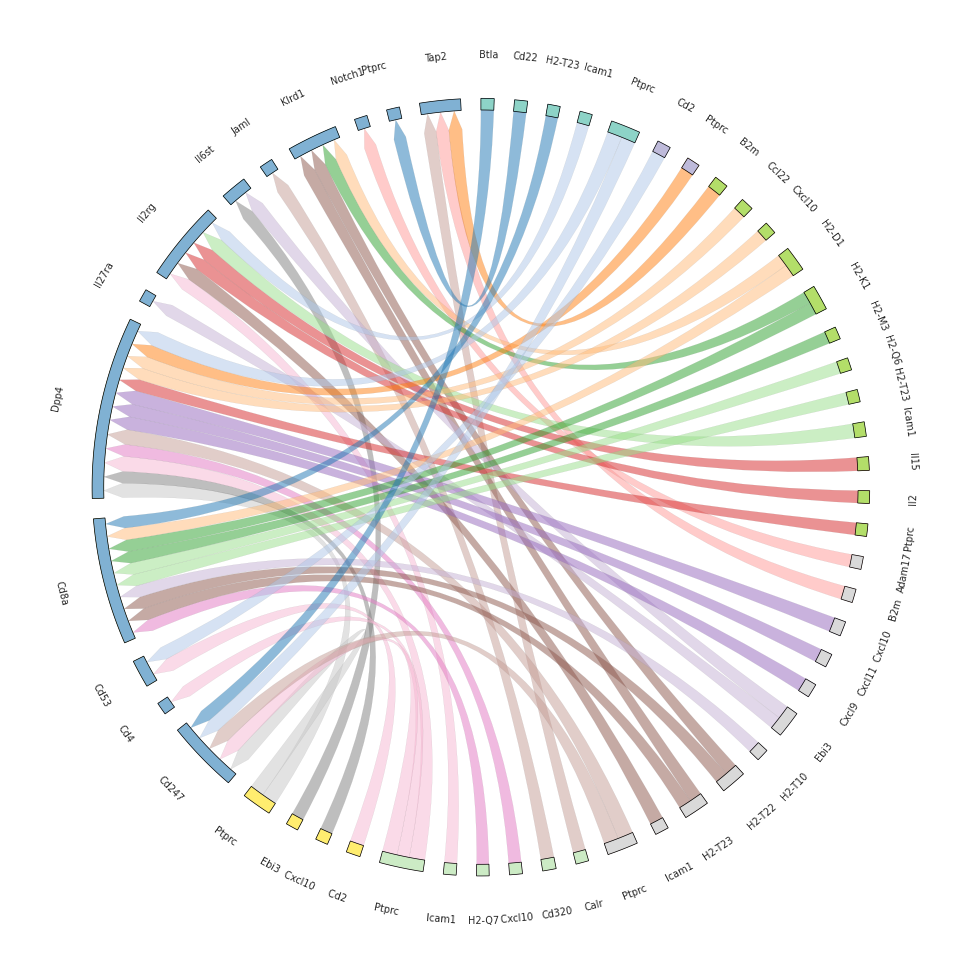

In [25]:
# Get top 50 ligand-receptor pairs
if "prioritization_score" in prior_table.columns:
    prior_table_oi = prior_table.nlargest(50, "prioritization_score")
    
    # Define colors for senders and receivers
    senders_receivers = sorted(
        set(prior_table_oi["sender"].tolist() + prior_table_oi["receiver"].tolist())
    )
    import matplotlib.cm as cm
    colors = cm.Set3(np.linspace(0, 1, len(senders_receivers)))
    celltype_colors = {ct: colors[i] for i, ct in enumerate(senders_receivers)}
    
    _ = nn.make_circos_lr(
        prior_table_oi,
        colors_sender=celltype_colors,
        colors_receiver=celltype_colors,
        show=True,
        figsize=(9, 9)
    )

### Visualization: Mushroom plot

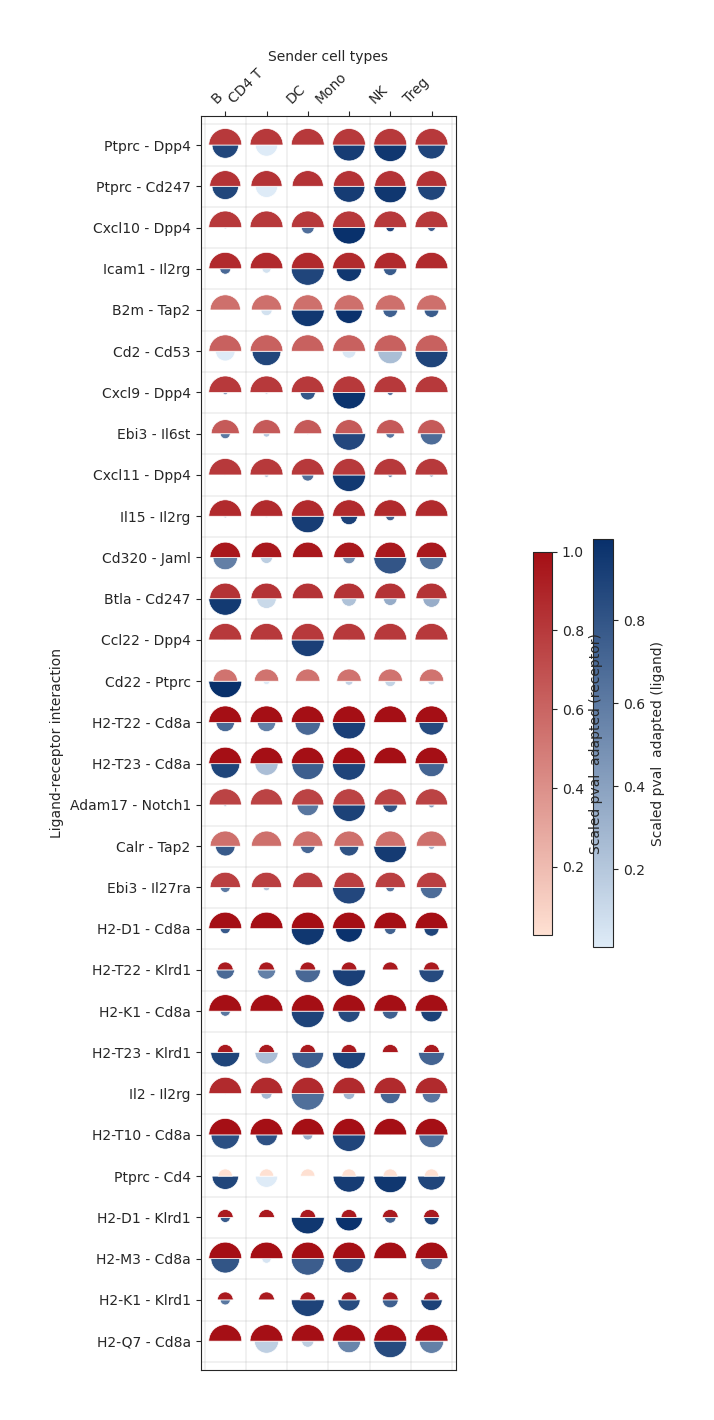

In [26]:
receiver_oi = "CD8 T"
_ = nn.make_mushroom_plot(
    prior_table[prior_table["receiver"] == receiver_oi],
    top_n=30,
    show=True,
)